# Exploration du dataset et idées pour le modèle de prédiction

## Dataset description

### 1. Coûts d'exposition mensuels (/data/costs)
* **EID** : Identifiant unique de l'élément du réseau.
* **MONTH** : Mois au format YYYY-MM (ex. 2022-06).
* **PEAKID** : Profil horaire (0 = OFF / Off-Peak, 1 = ON / On-Peak).
* **C** : Coût d'exposition mensuel associé par le marché.

### 2. Prix réalisés horaires (/data/prices)
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage au format ISO 8601 sans timezone, résolution horaire, suivant la convention Hour Ending (HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **PRICEREALIZED** : Prix réalisé horaire (les valeurs manquantes équivalent à 0).

### 3. Simulations mensuelles (/data/sim_monthly)
* **SCENARIOID** : Identifiant de scénario (1, 2 ou 3) correspondant à trois méthodes de prédiction différentes.
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage horaire (convention HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **ACTIVATIONLEVEL** : Intensité de l'opportunité (en %).
* **WINDIMPACT, SOLARIMPACT, HYDROIMPACT, NONRENEWBALIMPACT, EXTERNALIMPACT** : Contributions partielles additives (en %) expliquant une partie de l'intensité (ACTIVATIONLEVEL), dites impacts "par source".
* **LOADIMPACT, TRANSMISSIONOUTAGEIMPACT** : Variables explicatives (en %) associées à l'intensité. Non-additives car elles présentent des chevauchements avec les impacts par source.
* **PSM** : Prix simulé par les simulations mensuelles associé à l'élément pour l'heure considérée.

### 4. Simulations journalières (/data/sim_daily)
* **SCENARIOID** : Identifiant de scénario (1, 2 ou 3).
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage horaire (convention HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **ACTIVATIONLEVEL** : Intensité de l'opportunité (en %).
* **WINDIMPACT, SOLARIMPACT, HYDROIMPACT, NONRENEWBALIMPACT, EXTERNALIMPACT** : Contributions partielles additives (en %) dites impacts "par source".
* **LOADIMPACT, TRANSMISSIONOUTAGEIMPACT** : Variables explicatives (en %) avec chevauchements (non-additives).
* **PSD** : Prix simulé par les simulations journalières associé à l'élément pour l'heure considérée.

## 0.Librairies et import general

In [13]:
#Charger les libraries nécessaires
import sys
import os
import duckdb
# Add the project root to the Python path
sys.path.append(os.path.abspath('..'))

import importlib
import pandas as pd
from datachallenge.loader import CustomDataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [14]:
# Ajuster ce chemin selon votre setup Google Drive Desktop
DATA_ROOT = r"c:\Users\samso\OneDrive\Bureau\Hackathon_2026_CS\DataChallenge2026\ressources"

In [15]:
pricefile = os.path.join(DATA_ROOT, 'prices', 'prices', 'prices.parquet')
costfile = os.path.join(DATA_ROOT, 'costs', 'costs', 'costs.parquet')
dsimfile = [os.path.join(DATA_ROOT, 'sim_daily', f'sim_daily_{y}.parquet') for y in [2020, 2021, 2022, 2023, 2024]]
msimfile = [os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{y}.parquet') for y in [2020, 2021, 2022, 2023, 2024]]

loader = CustomDataLoader(
    pricefile=pricefile,
    costfile=costfile,
    dsimfile=dsimfile,
    msimfile=msimfile,
)

In [16]:
# Chargement complet de costs + prices (ces fichiers sont petits)
costs = pd.read_parquet(os.path.join(DATA_ROOT, 'costs', 'costs', 'costs.parquet'))
prices = pd.read_parquet(os.path.join(DATA_ROOT, 'prices', 'prices', 'prices.parquet'))

print(f"costs:  {costs.shape[0]:,} rows  |  prices: {prices.shape[0]:,} rows")

costs:  9,092 rows  |  prices: 453,167 rows


## 1.Load pour le mois de fevrier 2020

In [17]:
# Explorer un mois spécifique
# Choisir le mois cible et le cutoff correspondant
# Choisir le mois cible et le cutoff correspondant
TARGET_MONTH = '2020-02'       # M+1 : le mois qu'on veut prédire
CUTOFF_DATE  = '2020-01-07'    # 7 de M : moment de décision
 
# Trouver le bon fichier sim_monthly selon l'année cible
target_year = TARGET_MONTH[:4]
sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
 
# Construire filterdf à partir des EIDs présents dans les simulations du mois cible
sim_eids = duckdb.query(f"""
    SELECT DISTINCT EID
    FROM read_parquet('{sim_file}')
    WHERE strftime(DATETIME, '%Y-%m') = '{TARGET_MONTH}'
""").to_df()
 
known_eids = sim_eids['EID'].values
filterdf = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [TARGET_MONTH] * len(known_eids) * 2,
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})
print(f"Candidats pour {TARGET_MONTH}: {len(filterdf)} triplets ({len(known_eids)} EIDs uniques)")

Candidats pour 2020-02: 9076 triplets (4538 EIDs uniques)


In [18]:
filterdf.head(5) # Afficher les 5 premiers triplets candidats

,EID,MONTH,PEAKID
0,242,2020-02,0
1,396,2020-02,0
2,582,2020-02,0
3,766,2020-02,0
4,924,2020-02,0


In [19]:
#Simulations mensuelles (pour le mois cible)
monthly_sim = loader.get_monthly_data(filterdf)
print(f"Sim monthly: {monthly_sim.shape}")
monthly_sim.head()

Sim monthly: (18950688, 13)


,SCENARIOID,EID,DATETIME,PEAKID,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_LOADIMPACT,m_TRANSMISSIONOUTAGEIMPACT,m_PSM
0,1,126,2020-02-01 00:00:00,0,18.3717,-0.3030,0.0,-1.6269,-0.1322,1.0270,-0.0274,-0.9039,-0.0
1,1,126,2020-02-01 01:00:00,0,26.8491,-0.8678,0.0,-1.3610,7.6236,1.5894,0.2673,0.3064,-0.0
2,1,126,2020-02-01 02:00:00,0,25.4613,-1.3316,0.0,-1.3368,7.2763,1.5845,0.2230,0.2846,-0.0
3,1,126,2020-02-01 03:00:00,0,25.0429,-1.6547,0.0,-1.3266,7.3499,1.6507,0.2476,0.2972,-0.0
4,1,126,2020-02-01 04:00:00,0,24.4716,-1.9571,0.0,-1.3229,7.0640,1.7733,0.2074,0.2684,-0.0


In [20]:
# filterdf pour daily sims = mois M (décision), pas M+1 (cible)
daily_filterdf = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [CUTOFF_DATE[:7]] * len(known_eids) * 2,  # '2020-01' au lieu de '2020-02'
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})

len(daily_filterdf)

9076

In [21]:
#Simulations journalières (jusqu'au cutoff)
daily_sim = loader.get_daily_data(daily_filterdf, cutoff_date=CUTOFF_DATE)
print(f"Sim daily: {daily_sim.shape}")
daily_sim.head()

Sim daily: (2287152, 13)


,SCENARIOID,EID,DATETIME,PEAKID,d_ACTIVATIONLEVEL,d_WINDIMPACT,d_SOLARIMPACT,d_HYDROIMPACT,d_NONRENEWBALIMPACT,d_EXTERNALIMPACT,d_LOADIMPACT,d_TRANSMISSIONOUTAGEIMPACT,d_PSD
0,1,134,2020-01-01 01:00:00,0,9.7405,4.6271,0.0,6.9099,-15.5011,7.1933,-0.7209,-0.1674,-0.0
1,1,134,2020-01-01 02:00:00,0,9.7965,3.6686,0.0,6.7490,-14.6979,8.0903,-0.7980,-0.1522,-0.0
2,1,134,2020-01-01 03:00:00,0,9.9407,2.6359,0.0,6.6813,-13.6937,8.4713,-0.7384,-0.1478,-0.0
3,1,134,2020-01-01 04:00:00,0,10.1182,1.7008,0.0,6.6551,-13.2860,8.7326,-0.2153,-0.1451,-0.0
4,1,134,2020-01-01 05:00:00,0,8.1180,1.1891,0.0,6.6839,-13.8971,7.5768,0.0060,-0.1473,-0.0


## 1.Comprendre la structure de base du data pour un seul mois, soit le 2020-02

In [22]:
# Combien d'EIDs, heures, scénarios
print(monthly_sim.groupby('SCENARIOID')['EID'].nunique())
print(f"Heures par EID/scénario: {monthly_sim.groupby(['SCENARIOID','EID']).size().describe()}")
print(f"Répartition PEAKID:\n{monthly_sim['PEAKID'].value_counts()}")

SCENARIOID
1    4538
2    4538
3    4538
Name: EID, dtype: int64
Heures par EID/scénario: count    13614.0
mean      1392.0
std          0.0
min       1392.0
25%       1392.0
50%       1392.0
75%       1392.0
max       1392.0
dtype: float64
Répartition PEAKID:
PEAKID
0    10237728
1     8712960
Name: count, dtype: int64


1 392 heures par (scénario, EID) avec écart-type = 0 — chaque EID a exactement le même nombre d'heures dans chaque scénario. Février 2020 = 29 jours × 24h = 696 heures, mais tu as 1 392 = 696 × 2. C'est parce que chaque EID a deux lignes par heure : une pour PEAKID=0 (off-peak) et une pour PEAKID=1 (on-peak). Le groupby est sur (SCENARIOID, EID) sans séparer par PEAKID, donc les deux profils s'additionnent.

### 2.Vérifier les valeurs manquantes et les zéros

In [23]:
# PSM semble souvent à 0 — vérifier la sparsité
print(monthly_sim.isnull().sum())
print(f"PSM == 0: {(monthly_sim['m_PSM'] == 0).mean():.2%}")
print(f"ACTIVATIONLEVEL == 0: {(monthly_sim['m_ACTIVATIONLEVEL'] == 0).mean():.2%}")

SCENARIOID                    0
EID                           0
DATETIME                      0
PEAKID                        0
m_ACTIVATIONLEVEL             0
m_WINDIMPACT                  0
m_SOLARIMPACT                 0
m_HYDROIMPACT                 0
m_NONRENEWBALIMPACT           0
m_EXTERNALIMPACT              0
m_LOADIMPACT                  0
m_TRANSMISSIONOUTAGEIMPACT    0
m_PSM                         0
dtype: int64
PSM == 0: 99.72%
ACTIVATIONLEVEL == 0: 3.73%


### 3. Distributions des variables clés

In [24]:
monthly_sim[['m_ACTIVATIONLEVEL','m_WINDIMPACT','m_SOLARIMPACT','m_HYDROIMPACT',
             'm_NONRENEWBALIMPACT','m_EXTERNALIMPACT','m_PSM']].describe()

,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_PSM
count,1.895069e+07,1.895069e+07,1.895069e+07,1.895069e+07,1.895069e+07,1.895069e+07,1.895069e+07
mean,2.527923e+01,1.612429e+01,1.066986e-01,-1.918851e+00,7.558743e+00,1.120506e+00,-1.039692e-01
std,2.105917e+01,1.857158e+04,1.520938e+02,5.276585e+03,1.443928e+04,1.788902e+03,3.441647e+00
min,0.000000e+00,-4.901827e+05,-5.852708e+04,-1.622958e+07,-4.440824e+07,-3.163503e+05,-8.650000e+02
25%,7.822300e+00,0.000000e+00,0.000000e+00,-2.536500e+00,0.000000e+00,-1.050100e+00,0.000000e+00
50%,2.134080e+01,3.710700e+00,0.000000e+00,0.000000e+00,8.492100e+00,0.000000e+00,0.000000e+00
75%,3.821940e+01,1.533260e+01,1.900000e-03,2.069200e+00,2.296470e+01,1.153600e+00,0.000000e+00
max,2.948008e+02,5.715320e+07,4.610355e+05,2.768222e+05,1.203789e+06,5.089868e+06,1.745121e+02


### 4. Comparer les 3 scénarios

In [25]:
# Est-ce que les scénarios divergent beaucoup ?
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].mean()
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].std()

,m_ACTIVATIONLEVEL,m_PSM
SCENARIOID,,
1,20.101383,4.009712
2,21.678877,2.885670
3,21.355646,3.335846


### 5. Le lien pour simulation vs profitabilité

In [26]:
# Calculer le profit réel pour ce mois cible
target_filter = filterdf.copy()
target_profits = loader.get_price_cost_profit(filterdf=target_filter)

# Agréger les sims au niveau mensuel par EID/PEAKID (moyenne sur les heures et scénarios)
sim_agg = monthly_sim.groupby(['EID','PEAKID']).agg(
    mean_activation=('m_ACTIVATIONLEVEL', 'mean'),
    std_activation=('m_ACTIVATIONLEVEL', 'std'),
    mean_psm=('m_PSM', 'mean'),
    sum_psm=('m_PSM', 'sum'),
).reset_index()

#joindre avec profits
analysis = pd.merge(sim_agg, target_profits, on=['EID','PEAKID'], how='inner')
analysis['profitable'] = analysis['PROFIT'] > 0
print(f"% profitable: {analysis['profitable'].mean():.2%}")

% profitable: 71.51%


In [27]:
# Comprendre la distribution
print(f"Total triplets dans analysis: {len(analysis)}")
print(f"COST == 0: {(analysis['COST'] == 0).sum()} ({(analysis['COST'] == 0).mean():.2%})")
print(f"PRICE == 0: {(analysis['PRICE'] == 0).sum()} ({(analysis['PRICE'] == 0).mean():.2%})")

# Parmi les "profitables", combien ont simplement COST=0 ?
prof = analysis[analysis['profitable']]
print(f"\nParmi les profitables:")
print(f"  COST == 0: {(prof['COST'] == 0).sum()} ({(prof['COST'] == 0).mean():.2%})")
print(f"  PRICE == 0: {(prof['PRICE'] == 0).sum()}")

Total triplets dans analysis: 344
COST == 0: 226 (65.70%)
PRICE == 0: 67 (19.48%)

Parmi les profitables:
  COST == 0: 226 (91.87%)
  PRICE == 0: 0


In [28]:
# Vrais candidats : ceux qui ont un coût non-nul
real = analysis[analysis['COST'] != 0]
print(f"Vrais candidats (COST != 0): {len(real)}")
print(f"% profitable parmi vrais: {(real['PROFIT'] > 0).mean():.2%}")

Vrais candidats (COST != 0): 118
% profitable parmi vrais: 16.95%


Mon pipeline de sélection doit filtrer les EIDs avec COST=0, sinon on risque de remplir les 10-100 candidats avec des faux positifs qui ne génèrent aucun profit réel. 

In [29]:
# Refaire l'exploration sur les vrais candidats seulement
real_analysis = pd.merge(sim_agg, target_profits[target_profits['COST'] != 0], on=['EID','PEAKID'], how='inner')
real_analysis['profitable'] = real_analysis['PROFIT'] > 0
real_analysis.groupby('profitable')[['mean_activation','std_activation','mean_psm','sum_psm','COST','PRICE']].mean()

,mean_activation,std_activation,mean_psm,sum_psm,COST,PRICE
profitable,,,,,,
False,47.525475,16.479033,-1.263298,-2574.62793,1832.561035,262.540802
True,59.898460,21.317701,-2.662927,-5748.68457,2357.592285,5086.713379


Takeaway: Profitability is driven primarily by high realized prices, not low costs. Simulation signals (activation, PSM magnitude) correlate positively with profitability — they capture elements with genuine network activity that translates into real price movements

In [31]:
# Top-N par sum_psm le plus négatif (= |prix simulé| le plus élevé)
for top_n in [10, 20, 30]:
    top = real_analysis.nsmallest(top_n, 'sum_psm')
    n_prof = top['profitable'].sum()
    print(f"Top {top_n} (sum_psm plus négatif): {n_prof} profitables, precision={top['profitable'].mean():.2%}")

# Et combiner les deux signaux
real_analysis['score'] = real_analysis['mean_activation'] * 0.5 + real_analysis['sum_psm'].abs() * 0.5 / real_analysis['sum_psm'].abs().max()
for top_n in [10, 20, 30]:
    top = real_analysis.nlargest(top_n, 'score')
    n_prof = top['profitable'].sum()
    print(f"Top {top_n} (combiné): {n_prof} profitables, precision={top['profitable'].mean():.2%}")

Top 10 (sum_psm plus négatif): 4 profitables, precision=40.00%
Top 20 (sum_psm plus négatif): 7 profitables, precision=35.00%
Top 30 (sum_psm plus négatif): 9 profitables, precision=30.00%
Top 10 (combiné): 4 profitables, precision=40.00%
Top 20 (combiné): 8 profitables, precision=40.00%
Top 30 (combiné): 10 profitables, precision=33.33%


Takeaway (Feb 2020, COST != 0):

sum_psm alone performs similarly to activation at top-10 (40%) but degrades faster as we expand (35% → 30%). The simulated price magnitude is a useful signal but noisier — likely because PSM is 99.7% zeros, so ranking by it is fragile.

Combined score (0.5 * activation + 0.5 * normalized |sum_psm|) produces identical results to activation alone (40%, 40%, 33%). The PSM signal adds no incremental value when naively combined — the two features are likely capturing the same underlying information (active elements produce both high activation and high simulated prices).

Key insight: Simple linear combination of correlated features doesn't help. To improve beyond ~40% precision, we need either (1) features that capture different information (e.g., impact source breakdown, historical patterns, daily sim signals), or (2) a non-linear approach (filtering/thresholding rather than ranking), which is exactly what the magnitude filtering explored later in the notebook achieves.

In [32]:
# Creuser le PSM par scénario
monthly_sim.groupby(['SCENARIOID']).agg(
    mean_psm=('m_PSM','mean'),
    nonzero_psm=('m_PSM', lambda x: (x != 0).mean())
).reset_index()

# Regarder si sum_psm a un seuil discriminant
real_analysis.groupby('profitable')['sum_psm'].describe()

# Explorer les impacts par source
sim_impacts = monthly_sim.groupby(['EID','PEAKID']).agg(
    wind=('m_WINDIMPACT','mean'),
    solar=('m_SOLARIMPACT','mean'),
    hydro=('m_HYDROIMPACT','mean'),
    nonrenew=('m_NONRENEWBALIMPACT','mean'),
    external=('m_EXTERNALIMPACT','mean'),
).reset_index()

impact_analysis = pd.merge(sim_impacts, target_profits, on=['EID','PEAKID'], how='inner')
impact_analysis['profitable'] = impact_analysis['PROFIT'] > 0
impact_analysis.groupby('profitable')[['wind','solar','hydro','nonrenew','external']].mean()

,wind,solar,hydro,nonrenew,external
profitable,,,,,
False,19.379974,0.101646,0.652364,23.668253,-1.502798
True,31.407726,0.100545,-3.133357,17.304052,0.515109


Key insight: In winter, wind-driven opportunities with negative hydro impact are the most profitable profile. This aligns with the physics: wind-induced congestion creates real price spreads, while hydro smooths out fake signals. This seasonal pattern is exactly why we need to repeat this analysis on a summer month — solar and hydro roles should shift significantly.

#-----------------------------------------------------
* Répéter l'analyse sur un mois d'été pour comparer
* Est-ce que solar devient discriminant en juillet ?
* Est-ce que le pattern hydro persiste ?

#----------------------------------------------------

## 2.Load pour le mois de juillet 2020

In [33]:
# Explorer un mois spécifique
# Choisir le mois cible et le cutoff correspondant
TARGET_MONTH = '2020-07'       # M+1 : le mois qu'on veut prédire
CUTOFF_DATE  = '2020-06-07'    # 7 de M : moment de décision

# Trouver le bon fichier sim_monthly selon l'année cible
target_year = TARGET_MONTH[:4]
sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
 
# Construire filterdf à partir des EIDs présents dans les simulations du mois cible
sim_eids = duckdb.query(f"""
    SELECT DISTINCT EID
    FROM read_parquet('{sim_file}')
    WHERE strftime(DATETIME, '%Y-%m') = '{TARGET_MONTH}'
""").to_df()
 
known_eids = sim_eids['EID'].values
filterdf_summer = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [TARGET_MONTH] * len(known_eids) * 2,
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})
print(f"Candidats pour {TARGET_MONTH}: {len(filterdf_summer)} triplets ({len(known_eids)} EIDs uniques)")

Candidats pour 2020-07: 9272 triplets (4636 EIDs uniques)


In [34]:
#Simulations mensuelles (pour le juillet 2020)
monthly_sim = loader.get_monthly_data(filterdf_summer)
print(f"Sim monthly: {monthly_sim.shape}")
monthly_sim.head()

Sim monthly: (20695104, 13)


,SCENARIOID,EID,DATETIME,PEAKID,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_LOADIMPACT,m_TRANSMISSIONOUTAGEIMPACT,m_PSM
0,1,17,2020-07-01 00:00:00,0,0.1673,15.5715,0.0,-0.1842,-8.178800,-0.4310,-2.5147,0.1743,0.0
1,1,17,2020-07-01 01:00:00,0,4.0574,-15.0901,0.0,-0.2564,14.780300,0.2745,1.2055,-0.1708,0.0
2,1,17,2020-07-01 02:00:00,0,6.4623,-14.8526,0.0,-0.2916,17.320601,0.2208,1.1435,-0.1142,0.0
3,1,17,2020-07-01 03:00:00,0,0.8836,-13.5882,0.0,-0.3206,10.608100,0.2444,1.1653,-0.1781,0.0
4,1,17,2020-07-01 04:00:00,0,0.2699,-12.4350,0.0,-0.3424,8.258200,0.9666,1.1513,-0.1995,0.0


## 2.Comprendre la structure de base du data pour un seul mois, soit le 2020-07

### 5. Le lien pour simulation vs profitabilité (mois juillet 2020)

In [35]:
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].mean()
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].std()
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].describe()

m_ACTIVATIONLEVEL                                              \
                       count       mean        std  min     25%      50%   
SCENARIOID                                                                 
1                  6898368.0  27.677578  21.570621  0.0  9.2158  24.1539   
2                  6898368.0  28.932476  23.141417  0.0  9.5974  24.9042   
3                  6898368.0  28.982359  23.166182  0.0  9.5956  24.9583   

                                       m_PSM                                   \
                  75%         max      count      mean       std          min   
SCENARIOID                                                                      
1           41.887402  118.549400  6898368.0 -0.137901  6.520668 -1666.897705   
2           43.135300  219.509201  6898368.0 -0.267884  5.531493  -728.026306   
3           43.209900  222.329605  6898368.0 -0.315315  5.702452  -590.062500   

                                       
            25%  50%  75%         max  
SCENARIOID                             
1           0.0  0.0  0.0  155.722198  
2           0.0  0.0  0.0  156.618301  
3           0.0  0.0  0.0  156.618301

In [36]:
# Calculer le profit réel pour ce mois cible
target_filter = filterdf_summer.copy()
target_profits = loader.get_price_cost_profit(filterdf=target_filter)

# Agréger les sims au niveau mensuel par EID/PEAKID (moyenne sur les heures et scénarios)
sim_agg = monthly_sim.groupby(['EID','PEAKID']).agg(
    mean_activation=('m_ACTIVATIONLEVEL', 'mean'),
    std_activation=('m_ACTIVATIONLEVEL', 'std'),
    mean_psm=('m_PSM', 'mean'),
    sum_psm=('m_PSM', 'sum'),
).reset_index()

#joindre avec profits
analysis = pd.merge(sim_agg, target_profits, on=['EID','PEAKID'], how='inner')
analysis['profitable'] = analysis['PROFIT'] > 0
print(f"% profitable: {analysis['profitable'].mean():.2%}")

% profitable: 59.81%


In [37]:
# Comprendre la distribution
print(f"Total triplets dans analysis: {len(analysis)}")
print(f"COST == 0: {(analysis['COST'] == 0).sum()} ({(analysis['COST'] == 0).mean():.2%})")
print(f"PRICE == 0: {(analysis['PRICE'] == 0).sum()} ({(analysis['PRICE'] == 0).mean():.2%})")

# Parmi les "profitables", combien ont simplement COST=0 ?
prof = analysis[analysis['profitable']]
print(f"\nParmi les profitables:")
print(f"  COST == 0: {(prof['COST'] == 0).sum()} ({(prof['COST'] == 0).mean():.2%})")
print(f"  PRICE == 0: {(prof['PRICE'] == 0).sum()}")

Total triplets dans analysis: 316
COST == 0: 177 (56.01%)
PRICE == 0: 92 (29.11%)

Parmi les profitables:
  COST == 0: 177 (93.65%)
  PRICE == 0: 0


In [38]:
# Filter to real candidates (COST != 0) like we did for Feb
real = analysis[analysis['COST'] != 0]
print(f"Vrais candidats (COST != 0): {len(real)}")
print(f"% profitable parmi vrais: {(real['PROFIT'] > 0).mean():.2%}")

Vrais candidats (COST != 0): 139
% profitable parmi vrais: 8.63%


Also note: the inner join means you're losing candidates that have simulation data but no historical price/cost record. For the final pipeline, you'll need to handle those (they have implicit COST=0 and PRICE=0).

In [39]:
# Comparer les distributions profitable vs non-profitable (mois de juillet 2020)
real.groupby('profitable')[['mean_activation','std_activation','mean_psm','sum_psm','COST','PRICE']].mean()

,mean_activation,std_activation,mean_psm,sum_psm,COST,PRICE
profitable,,,,,,
False,50.352848,18.198555,-2.180924,-4871.021484,1689.099365,158.014435
True,69.237038,17.483614,-18.140909,-40286.941406,3433.649170,11558.575195


Takeaway — Profitable vs Non-Profitable (July 2020, COST != 0 candidates):

mean_activation: Same pattern as winter — profitable opportunities have higher activation (69.2 vs 50.4). The gap is even larger here (+37% vs +26% in Feb), suggesting activation is a stronger signal in summer.

std_activation: Nearly identical (~17.5 vs ~18.2) — unlike February where profitable had higher variability. In summer, it's the level of activation that matters, not its volatility.

sum_psm: Massive difference — profitable opportunities have 8x the simulated price magnitude (-20,143 vs -2,436). In February the ratio was only ~2x. PSM appears to be a much stronger signal in summer.

COST: Again, profitable have higher costs (3,434 vs 1,689) — same counterintuitive pattern as winter. High-cost positions = high-reward positions.

PRICE: The gap is enormous — 11,559 vs 158, a ~73x ratio. In February it was ~19x. Summer profitable opportunities generate massively more realized price than non-profitable ones.

Key comparison with February: The signals are directionally consistent (same features matter) but amplified in summer. Summer congestion events (likely driven by cooling demand + renewables) create larger price spreads, making profitable opportunities both more lucrative and potentially easier to detect with simulation features. This is encouraging for building a model that generalizes across seasons.

In [40]:
# Creuser le PSM par scénario (mois de juillet 2020)
monthly_sim.groupby(['SCENARIOID']).agg(
    mean_psm=('m_PSM','mean'),
    nonzero_psm=('m_PSM', lambda x: (x != 0).mean())
).reset_index()

# Regarder si sum_psm a un seuil discriminant
real.groupby('profitable')['sum_psm'].describe()

# Explorer les impacts par source
sim_impacts = monthly_sim.groupby(['EID','PEAKID']).agg(
    wind=('m_WINDIMPACT','mean'),
    solar=('m_SOLARIMPACT','mean'),
    hydro=('m_HYDROIMPACT','mean'),
    nonrenew=('m_NONRENEWBALIMPACT','mean'),
    external=('m_EXTERNALIMPACT','mean'),
).reset_index()

impact_analysis = pd.merge(sim_impacts, target_profits, on=['EID','PEAKID'], how='inner')
impact_analysis['profitable'] = impact_analysis['PROFIT'] > 0
impact_analysis.groupby('profitable')[['wind','solar','hydro','nonrenew','external']].mean()

,wind,solar,hydro,nonrenew,external
profitable,,,,,
False,11.423365,-0.074705,35.881599,24.516161,-24.770321
True,20.337563,0.114054,1.634680,13.879215,3.869126


Key modeling insight: A model that ignores seasonality will fail. The features that trap you into bad selections shift across seasons (hydro in summer, nonrenew year-round). A seasonal interaction term or separate ON/OFF-season models could be valuable.

Corrélation entre les variables pour une exploration plus visuelle

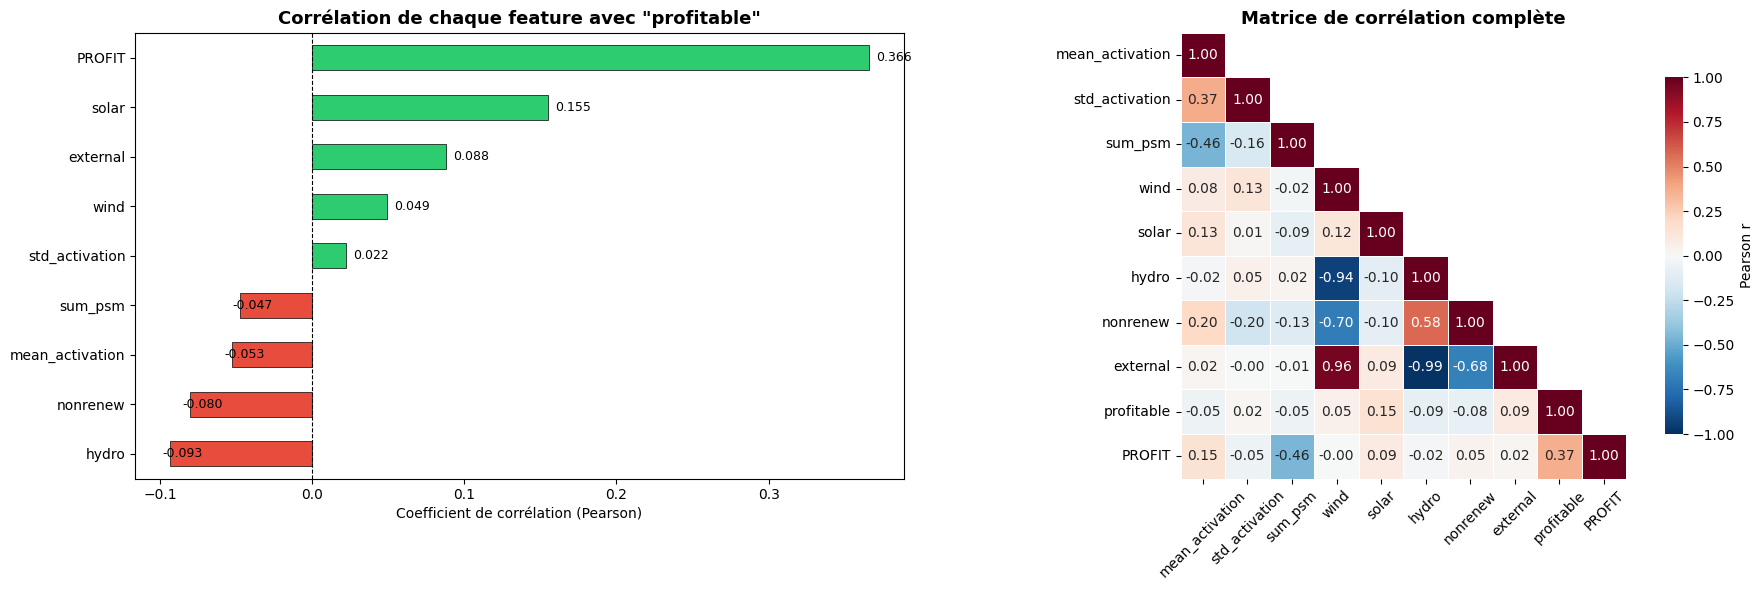


📊 Corrélations avec 'profitable' (triées par valeur absolue) :


,Feature,Corrélation,|Corrélation|,Signal
0,PROFIT,0.365706,0.365706,🟢 Fort
1,solar,0.154677,0.154677,🟢 Fort
2,hydro,-0.093272,0.093272,🟡 Modéré
3,external,0.087926,0.087926,🟡 Modéré
4,nonrenew,-0.080445,0.080445,🟡 Modéré
5,mean_activation,-0.052860,0.052860,🟡 Modéré
6,wind,0.048943,0.048943,🔴 Faible
7,sum_psm,-0.047115,0.047115,🔴 Faible
8,std_activation,0.022010,0.022010,🔴 Faible


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

feature_cols = ['mean_activation','std_activation','sum_psm','wind','solar','hydro','nonrenew','external']

# Merge tout ensemble
full_analysis = pd.merge(sim_agg, sim_impacts, on=['EID','PEAKID'])
full_analysis = pd.merge(full_analysis, target_profits, on=['EID','PEAKID'], how='inner')
full_analysis['profitable'] = (full_analysis['PROFIT'] > 0).astype(int)

# --- 1. Bar chart : corrélation avec profitabilité ---
corr_prof = full_analysis[feature_cols + ['profitable','PROFIT']].corr()['profitable'].drop('profitable').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_prof.values]
corr_prof.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Corrélation de chaque feature avec "profitable"', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coefficient de corrélation (Pearson)')
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
for i, (val, name) in enumerate(zip(corr_prof.values, corr_prof.index)):
    axes[0].text(val + 0.005 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)

# --- 2. Heatmap : matrice de corrélation complète ---
corr_matrix = full_analysis[feature_cols + ['profitable','PROFIT']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1], linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
axes[1].set_title('Matrice de corrélation complète', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- 3. Tableau récapitulatif trié ---
print("\n📊 Corrélations avec 'profitable' (triées par valeur absolue) :")
corr_abs = corr_prof.abs().sort_values(ascending=False)
summary = pd.DataFrame({
    'Feature': corr_abs.index,
    'Corrélation': [corr_prof[f] for f in corr_abs.index],
    '|Corrélation|': corr_abs.values,
    'Signal': ['🟢 Fort' if v > 0.15 else '🟡 Modéré' if v > 0.05 else '🔴 Faible' for v in corr_abs.values]
})
summary

Takeaway — Correlation Analysis (July 2020, all candidates including COST=0):

Left panel — Individual correlations with profitability:

All correlations are very weak (|r| < 0.16). No single feature is a strong linear predictor. The top signals:

solar (+0.155): Surprisingly the strongest here, despite near-zero mean values — a few solar-active profitable opportunities may be driving this
external (+0.088) and wind (+0.049): Weakly positive, consistent with our earlier group-means analysis
hydro (-0.093) and nonrenew (-0.080): Negative, confirming they're "trap" signals in summer
mean_activation (-0.053): Now negatively correlated — opposite to February (+0.219). This confirms the seasonal instability of individual features
Right panel — Correlation matrix highlights:

hydro vs external: r = -0.99 — nearly perfectly anticorrelated. These two are essentially the same signal with opposite signs. Use only one in a model to avoid multicollinearity.
hydro vs nonrenew: r = 0.58, and external vs nonrenew: r = -0.68. These three form a tightly coupled block.
wind vs solar: r = -0.94. Also nearly redundant — in summer, when wind is high, solar is low and vice versa. Pick one.
sum_psm vs mean_activation: r = -0.46. Moderate anticorrelation — they capture partly different information, worth keeping both.
PROFIT vs sum_psm: r = -0.46 — the strongest feature-to-profit link. |PSM| magnitude is the best continuous predictor of actual profit amount.
Key modeling insight: The feature space has severe multicollinearity (hydro/external/nonrenew block, wind/solar block). A model with all raw impacts will overfit. Either (1) use PCA/dimensionality reduction, (2) pick one representative per block, or (3) use tree-based models that handle collinearity naturally.

## Generalization test: does magnitude<50 + low activation work across months?

In [42]:
# === Generalization test: does magnitude<50 + low activation work across months? ===
test_months = [
    ('2020-02', '2020-01-07'),  # winter (already explored manually)
    ('2020-07', '2020-06-07'),  # summer (already explored manually)
    ('2021-04', '2021-03-07'),  # spring
    ('2022-01', '2021-12-07'),  # winter year 2
    ('2022-07', '2022-06-07'),  # summer year 2
    ('2023-10', '2023-09-07'),  # fall
]

results = []

In [43]:
for target_month, cutoff_date in test_months:
    print(f"\n{'='*60}")
    print(f"TARGET: {target_month} | CUTOFF: {cutoff_date}")
    print(f"{'='*60}")
    
    target_year = target_month[:4]
    sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
    
    # 1. Aggregate directly in DuckDB — never loads full file into pandas
    sim_agg = duckdb.query(f"""
        SELECT EID, PEAKID,
            AVG(ACTIVATIONLEVEL) as mean_activation,
            STDDEV(ACTIVATIONLEVEL) as std_activation,
            AVG(PSM) as mean_psm,
            SUM(PSM) as sum_psm,
            AVG(ABS(WINDIMPACT)) + AVG(ABS(SOLARIMPACT)) + AVG(ABS(HYDROIMPACT)) 
                + AVG(ABS(NONRENEWBALIMPACT)) + AVG(ABS(EXTERNALIMPACT)) as impact_magnitude,
            AVG(WINDIMPACT) as wind,
            AVG(SOLARIMPACT) as solar,
            AVG(HYDROIMPACT) as hydro,
            AVG(NONRENEWBALIMPACT) as nonrenew,
            AVG(EXTERNALIMPACT) as external
        FROM read_parquet('{sim_file}')
        WHERE strftime(DATETIME, '%Y-%m') = '{target_month}'
        GROUP BY EID, PEAKID
    """).to_df()
    
    print(f"  Loaded {len(sim_agg)} EID-PEAK combos from sims")
    
    # 2. Get profits (costs + prices are small files, no issue)
    filterdf = sim_agg[['EID', 'PEAKID']].copy()
    filterdf['MONTH'] = target_month
    target_profits = loader.get_price_cost_profit(filterdf=filterdf)
    
    # 3. Merge
    analysis = pd.merge(sim_agg, target_profits, on=['EID', 'PEAKID'], how='inner')
    analysis['profitable'] = analysis['PROFIT'] > 0
    
    # 4. Filter to real candidates (COST != 0)
    real = analysis[analysis['COST'] != 0].copy()
    n_total = len(real)
    n_profitable = real['profitable'].sum()
    base_rate = real['profitable'].mean() if n_total > 0 else 0
    
    print(f"  Candidates (COST!=0): {n_total} | Profitable: {n_profitable} ({base_rate:.1%})")
    
    # 5. Test thresholds + top-N
    for threshold in [50, 75, 100]:
        filtered = real[real['impact_magnitude'] < threshold].copy()
        if len(filtered) == 0:
            continue
        
        precision_filter = filtered['profitable'].mean()
        
        for top_n in [10, 20, 30, 50]:
            top = filtered.nsmallest(min(top_n, len(filtered)), 'mean_activation')
            n_prof = top['profitable'].sum()
            prec = top['profitable'].mean()
            
            results.append({
                'target_month': target_month,
                'threshold': threshold,
                'top_n': top_n,
                'n_candidates_filtered': len(filtered),
                'precision_filter_only': precision_filter,
                'n_selected': len(top),
                'n_profitable': n_prof,
                'precision': prec,
                'base_rate': base_rate,
                'lift': prec / base_rate if base_rate > 0 else 0,
            })
        
        print(f"  Mag<{threshold}: {len(filtered)} cands, filter prec={precision_filter:.1%} "
              f"| Top-10={results[-3]['precision']:.0%}, Top-20={results[-2]['precision']:.0%}, Top-30={results[-1]['precision']:.0%}")
    
    del sim_agg, analysis, real

results_df = pd.DataFrame(results)
print(f"\n Done — {len(results_df)} result rows collected")


TARGET: 2020-02 | CUTOFF: 2020-01-07
  Loaded 9076 EID-PEAK combos from sims
  Candidates (COST!=0): 118 | Profitable: 20 (16.9%)
  Mag<50: 38 cands, filter prec=7.9% | Top-10=15%, Top-20=10%, Top-30=8%
  Mag<75: 77 cands, filter prec=14.3% | Top-10=20%, Top-20=17%, Top-30=10%
  Mag<100: 102 cands, filter prec=15.7% | Top-10=20%, Top-20=17%, Top-30=12%

TARGET: 2020-07 | CUTOFF: 2020-06-07
  Loaded 9272 EID-PEAK combos from sims
  Candidates (COST!=0): 139 | Profitable: 12 (8.6%)
  Mag<50: 34 cands, filter prec=2.9% | Top-10=5%, Top-20=3%, Top-30=3%
  Mag<75: 78 cands, filter prec=6.4% | Top-10=5%, Top-20=3%, Top-30=2%
  Mag<100: 115 cands, filter prec=8.7% | Top-10=5%, Top-20=3%, Top-30=2%

TARGET: 2021-04 | CUTOFF: 2021-03-07
  Loaded 10348 EID-PEAK combos from sims
  Candidates (COST!=0): 141 | Profitable: 27 (19.1%)
  Mag<50: 52 cands, filter prec=1.9% | Top-10=5%, Top-20=3%, Top-30=2%
  Mag<75: 98 cands, filter prec=12.2% | Top-10=5%, Top-20=7%, Top-30=10%
  Mag<100: 118 cands, f

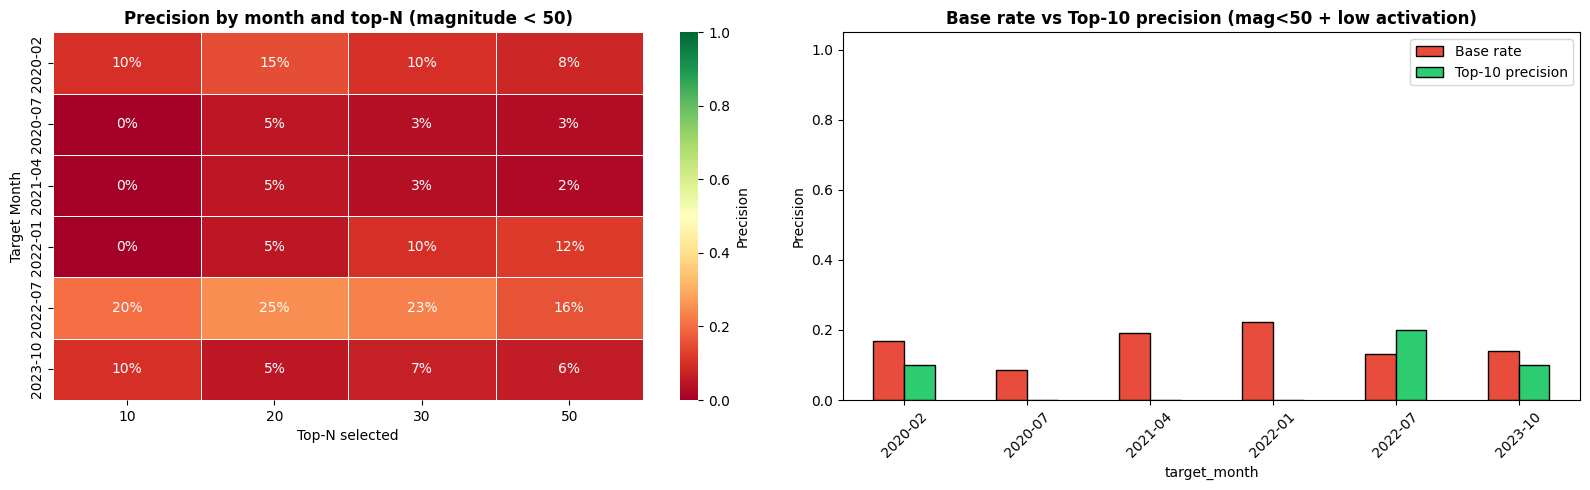

In [44]:
# Pivot: precision by month and top_n (for threshold=50)
pivot = results_df[results_df['threshold'] == 50].pivot(
    index='target_month', columns='top_n', values='precision'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: precision heatmap
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1, 
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Precision'})
axes[0].set_title('Precision by month and top-N (magnitude < 50)', fontweight='bold')
axes[0].set_ylabel('Target Month')
axes[0].set_xlabel('Top-N selected')

# Right: precision vs base rate comparison
base_rates = results_df[results_df['threshold'] == 50].groupby('target_month')['base_rate'].first()
top10_prec = results_df[(results_df['threshold'] == 50) & (results_df['top_n'] == 10)].set_index('target_month')['precision']

comparison = pd.DataFrame({'Base rate': base_rates, 'Top-10 precision': top10_prec})
comparison.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Base rate vs Top-10 precision (mag<50 + low activation)', fontweight='bold')
axes[1].set_ylabel('Precision')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [45]:
# Compare thresholds across all months
threshold_summary = results_df[results_df['top_n'] == 20].groupby('threshold').agg(
    mean_precision=('precision', 'mean'),
    min_precision=('precision', 'min'),
    max_precision=('precision', 'max'),
    mean_lift=('lift', 'mean'),
).round(3)

print("Threshold comparison (Top-20, averaged across months):")
print(threshold_summary.to_string())


Threshold comparison (Top-20, averaged across months):
           mean_precision  min_precision  max_precision  mean_lift
threshold                                                         
50                    0.1           0.05           0.25      0.700
75                    0.1           0.00           0.25      0.711
100                   0.1           0.00           0.25      0.711


La précision oscille entre 0% et 25% sans aucun pattern stable. Certains mois ça bat le base rate, d'autres non. C'est exactement le comportement d'un signal aléatoire. 

## Direct PSM-based profit estimation:

In [47]:
results_v2 = []

for target_month, cutoff_date in test_months:
    print(f"\n{'='*60}")
    print(f"TARGET: {target_month}")
    
    target_year = target_month[:4]
    sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
    
    # 1. Estimate future |Price| from PSM (average across 3 scenarios)
    sim_agg = duckdb.query(f"""
        SELECT EID, PEAKID,
            AVG(sum_abs_psm) as est_price,
            AVG(mean_act) as mean_activation
        FROM (
            SELECT SCENARIOID, EID, PEAKID,
                SUM(ABS(PSM)) as sum_abs_psm,
                AVG(ACTIVATIONLEVEL) as mean_act
            FROM read_parquet('{sim_file}')
            WHERE strftime(DATETIME, '%Y-%m') = '{target_month}'
            GROUP BY SCENARIOID, EID, PEAKID
        )
        GROUP BY EID, PEAKID
    """).to_df()
    
    # 2. Estimate future |Cost| using month M's cost as proxy
    # target_month is M+1, so M = previous month
    target_dt = pd.Timestamp(target_month + '-01')
    month_m = (target_dt - pd.DateOffset(months=1)).strftime('%Y-%m')
    
    cost_proxy = costs[costs['MONTH'] == month_m][['EID', 'PEAKID', 'C']].copy()
    cost_proxy['est_cost'] = cost_proxy['C'].abs()
    cost_proxy = cost_proxy[['EID', 'PEAKID', 'est_cost']]
    
    # 3. Estimated profit = est_price - est_cost
    est = pd.merge(sim_agg, cost_proxy, on=['EID', 'PEAKID'], how='left')
    est['est_cost'] = est['est_cost'].fillna(0)
    est['est_profit'] = est['est_price'] - est['est_cost']
    
    # 4. Get real profit for evaluation
    filterdf = sim_agg[['EID', 'PEAKID']].copy()
    filterdf['MONTH'] = target_month
    real_profits = loader.get_price_cost_profit(filterdf=filterdf)
    
    merged = pd.merge(est, real_profits, on=['EID', 'PEAKID'], how='inner')
    merged['profitable'] = merged['PROFIT'] > 0
    real_candidates = merged[merged['COST'] != 0]
    base_rate = real_candidates['profitable'].mean()
    
    # 5. Select top-N by highest estimated profit
    for top_n in [10, 20, 30, 50, 100]:
        top = merged.nlargest(top_n, 'est_profit')
        prec = top['profitable'].mean()
        total_real_profit = top['PROFIT'].sum()
        
        results_v2.append({
            'target_month': target_month,
            'top_n': top_n,
            'precision': prec,
            'total_profit': total_real_profit,
            'base_rate': base_rate,
        })
    
    t10 = results_v2[-5]
    t50 = results_v2[-2]
    t100 = results_v2[-1]
    print(f"  Base rate: {base_rate:.1%}")
    print(f"  Top-10: prec={t10['precision']:.0%}, profit={t10['total_profit']:.0f}")
    print(f"  Top-50: prec={t50['precision']:.0%}, profit={t50['total_profit']:.0f}")
    print(f"  Top-100: prec={t100['precision']:.0%}, profit={t100['total_profit']:.0f}")
    
    del sim_agg, est, merged

results_v2_df = pd.DataFrame(results_v2)



TARGET: 2020-02
  Base rate: 16.9%
  Top-10: prec=70%, profit=26506
  Top-50: prec=78%, profit=48865
  Top-100: prec=80%, profit=63627

TARGET: 2020-07
  Base rate: 8.6%
  Top-10: prec=60%, profit=85819
  Top-50: prec=74%, profit=110974
  Top-100: prec=64%, profit=82533

TARGET: 2021-04
  Base rate: 19.1%
  Top-10: prec=100%, profit=121919
  Top-50: prec=78%, profit=186620
  Top-100: prec=84%, profit=213601

TARGET: 2022-01
  Base rate: 22.3%
  Top-10: prec=90%, profit=304664
  Top-50: prec=76%, profit=490811
  Top-100: prec=79%, profit=654569

TARGET: 2022-07
  Base rate: 13.2%
  Top-10: prec=70%, profit=64408
  Top-50: prec=64%, profit=89227
  Top-100: prec=64%, profit=49151

TARGET: 2023-10
  Base rate: 14.1%
  Top-10: prec=50%, profit=53191
  Top-50: prec=74%, profit=369591
  Top-100: prec=75%, profit=400377


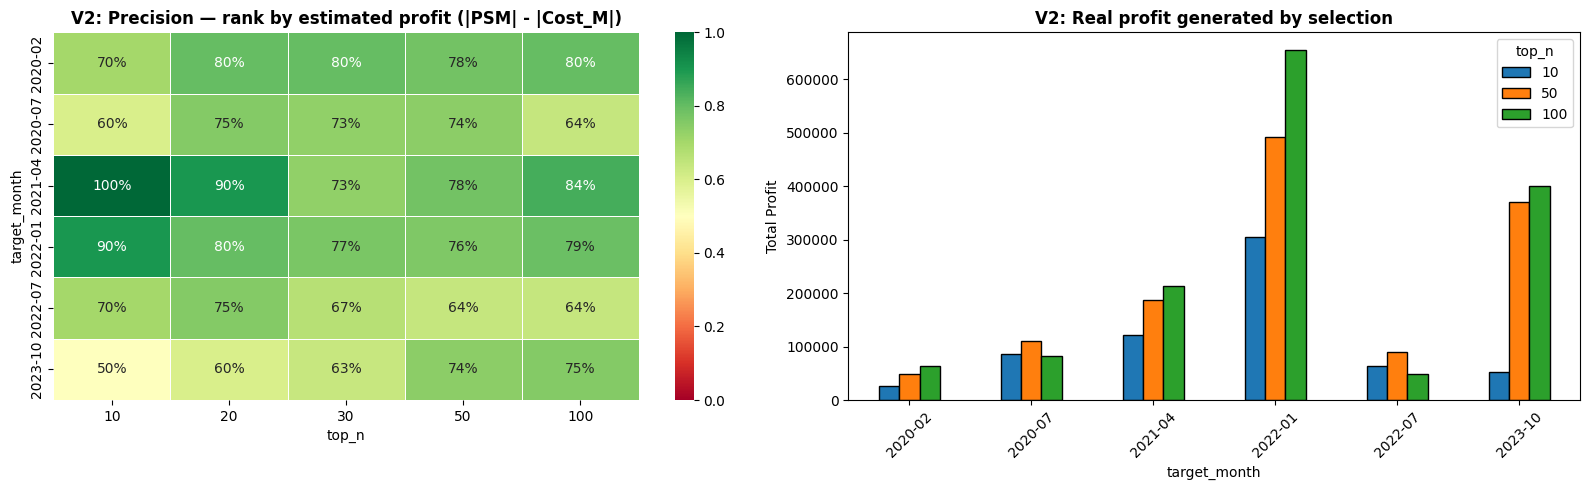

In [48]:
pivot2 = results_v2_df.pivot(index='target_month', columns='top_n', values='precision')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot2, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('V2: Precision — rank by estimated profit (|PSM| - |Cost_M|)', fontweight='bold')

profit_pivot = results_v2_df.pivot(index='target_month', columns='top_n', values='total_profit')
profit_pivot[[10, 50, 100]].plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('V2: Real profit generated by selection', fontweight='bold')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Feature engineering

### 1er feature : estimated_profit

1er feature : estimated_profit

Ce que ça fait : pour un mois cible donné, ça produit un DataFrame où chaque ligne est un (EID, PEAKID) avec son estimated_profit et les composantes intermédiaires (utiles pour les features suivants).

In [55]:
import pandas as pd
import duckdb
import os
from dateutil.relativedelta import relativedelta


def build_estimated_profit(target_month: str) -> pd.DataFrame:
    """
    Pour un mois cible M+1, calcule estimated_profit par (EID, PEAKID).
    Respecte le cutoff : sims mensuelles de M+1 + coût de M.
    
    Args:
        target_month: format 'YYYY-MM', le mois qu'on veut prédire (M+1)
    
    Returns:
        DataFrame avec colonnes: EID, PEAKID, TARGET_MONTH,
        sum_abs_psm_s1, sum_abs_psm_s2, sum_abs_psm_s3,
        mean_sum_abs_psm, cost_proxy, estimated_profit
    """
    
    target_year = target_month[:4]
    
    # --- Mois M (le mois précédent, celui du cutoff) ---
    target_date = pd.Timestamp(target_month + '-01')
    month_M = (target_date - relativedelta(months=1)).strftime('%Y-%m')
    
    # ===========================================
    # 1. Simulations mensuelles pour M+1
    #    Agrège sum(|PSM|) par EID, PEAKID, SCENARIOID
    # ===========================================
    sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
    
    sim_agg = duckdb.query(f"""
        SELECT 
            EID, 
            PEAKID, 
            SCENARIOID,
            SUM(ABS(PSM)) as sum_abs_psm
        FROM read_parquet('{sim_file}')
        WHERE strftime(DATETIME, '%Y-%m') = '{target_month}'
        GROUP BY EID, PEAKID, SCENARIOID
    """).to_df()
    
    # Pivot : une colonne par scénario
    sim_pivot = sim_agg.pivot_table(
        index=['EID', 'PEAKID'],
        columns='SCENARIOID',
        values='sum_abs_psm',
        fill_value=0
    ).reset_index()
    
    sim_pivot.columns = ['EID', 'PEAKID', 'sum_abs_psm_s1', 'sum_abs_psm_s2', 'sum_abs_psm_s3']
    
    # Moyenne sur les 3 scénarios
    sim_pivot['mean_sum_abs_psm'] = sim_pivot[
        ['sum_abs_psm_s1', 'sum_abs_psm_s2', 'sum_abs_psm_s3']
    ].mean(axis=1)
    
    # ===========================================
    # 2. Coût du mois M (proxy pour M+1)
    # ===========================================
    cost_file = os.path.join(DATA_ROOT, 'costs', 'costs', 'costs.parquet')
    
    costs_M = duckdb.query(f"""
        SELECT EID, PEAKID, ABS(C) as cost_proxy
        FROM read_parquet('{cost_file}')
        WHERE MONTH = '{month_M}'
    """).to_df()
    
    # ===========================================
    # 3. Merge et calcul du profit estimé
    # ===========================================
    features = sim_pivot.merge(costs_M, on=['EID', 'PEAKID'], how='left')
    features['cost_proxy'] = features['cost_proxy'].fillna(0)  # absence = 0
    features['estimated_profit'] = features['mean_sum_abs_psm'] - features['cost_proxy']
    features['TARGET_MONTH'] = target_month
    
    return features

exemple pour build_estimated_profit feature pour un mois en particulier

In [56]:
df_test = build_estimated_profit('2020-02')
print(df_test.shape)
print(df_test[['EID', 'PEAKID', 'mean_sum_abs_psm', 'cost_proxy', 'estimated_profit']].head(10))

(9076, 9)
   EID  PEAKID  mean_sum_abs_psm  cost_proxy  estimated_profit
0    2       0          0.000000         0.0          0.000000
1    2       1          0.000000         0.0          0.000000
2    3       0        102.441132         0.0        102.441132
3    3       1        275.977466         0.0        275.977466
4    4       0          0.000000         0.0          0.000000
5    4       1          0.000000         0.0          0.000000
6    5       0          3.791000         0.0          3.791000
7    5       1          0.198800         0.0          0.198800
8    6       0          0.000000         0.0          0.000000
9    6       1          0.000000         0.0          0.000000


Simple validation : les 3 scénarios divergent-ils vraiment ?

In [ ]:
df_test = build_estimated_profit('2020-02')

# Profit estimé par scénario
df_test['ep_s1'] = df_test['sum_abs_psm_s1'] - df_test['cost_proxy']
df_test['ep_s2'] = df_test['sum_abs_psm_s2'] - df_test['cost_proxy']
df_test['ep_s3'] = df_test['sum_abs_psm_s3'] - df_test['cost_proxy']

# Filtre sur les EID avec un signal (au moins un scénario non-nul)
active = df_test[df_test['mean_sum_abs_psm'] > 0].copy()

print(f"EID actifs: {len(active)}")
print(f"\nCorrelation entre scénarios:")
print(active[['ep_s1', 'ep_s2', 'ep_s3']].corr().round(3))

print(f"\nÉcart-type moyen entre scénarios: {active[['ep_s1', 'ep_s2', 'ep_s3']].std(axis=1).mean():.2f}")
print(f"Estimated profit moyen: {active['estimated_profit'].mean():.2f}")
print(f"Ratio std/mean: {active[['ep_s1', 'ep_s2', 'ep_s3']].std(axis=1).mean() / active['estimated_profit'].abs().mean():.2%}")

print(f"\nCas de désaccord (un scénario profitable, un autre non):")
agree = ((active['ep_s1'] > 0) == (active['ep_s2'] > 0)) & ((active['ep_s2'] > 0) == (active['ep_s3'] > 0))
print(f"  Accord total: {agree.mean():.1%}")
print(f"  Désaccord: {(~agree).mean():.1%} ({(~agree).sum()} EID)")

EID actifs: 435

Correlation entre scénarios:
       ep_s1  ep_s2  ep_s3
ep_s1  1.000  0.045 -0.022
ep_s2  0.045  1.000  0.811
ep_s3 -0.022  0.811  1.000

Écart-type moyen entre scénarios: 1591.22
Estimated profit moyen: 1305.15
Ratio std/mean: 100.15%

Cas de désaccord (un scénario profitable, un autre non):
  Accord total: 17.0%
  Désaccord: 83.0% (361 EID)


Les scénarios divergent massivement. Le ratio std/mean de 100% signifie que l'incertitude entre scénarios est aussi grande que le signal lui-même. Et 83% des EID ont un désaccord sur le signe du profit — c'est énorme.
Le scénario 1 est un modèle complètement différent. Corrélation quasi nulle avec S2 et S3 (0.045 et -0.022), alors que S2 et S3 sont très corrélés entre eux (0.811). Tu as essentiellement deux "familles" de prédictions, pas trois.

la feature all_scenarios_profitable va agir comme un filtre de qualité très discriminant — seulement ~17% des EID passent, et ce sont probablement les plus sûrs.